# Reseau dense sur dataset non lineaire

**But** : entrainer un petit reseau `Dense -> ReLU -> Dense -> Sigmoid`.

**Pourquoi** : verifier visuellement qu'un reseau non lineaire apprend une frontiere impossible pour un neurone seul.


In [1]:
import os
import sys
from pathlib import Path


import matplotlib.pyplot as plt
import numpy as np

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

ROOT = Path.cwd().resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.activations import ReLU, Sigmoid
from src.layers import Dense
from src.losses import BinaryCrossEntropy
from src.models import Sequential
from src.optim import SGD
from src.training.sequential import train_binary_classifier

plt.style.use("default")
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7)


**But** : construire deux anneaux concentriques bruités.

**Pourquoi** : un neurone linéaire ne peut pas séparer ce problème, un petit réseau oui.


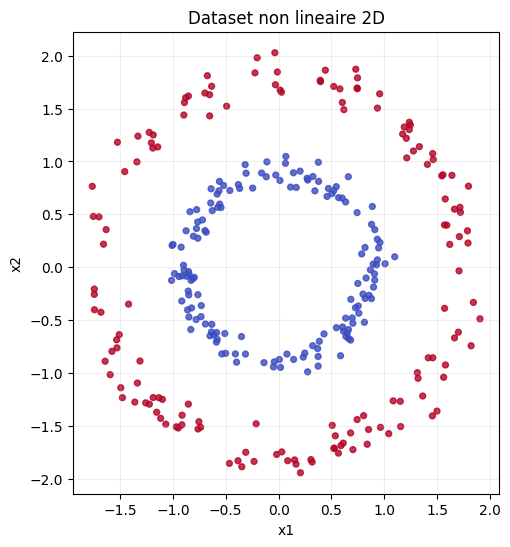

In [2]:
points_per_class = 150

angles_inner = rng.uniform(0.0, 2.0 * np.pi, size=points_per_class)
angles_outer = rng.uniform(0.0, 2.0 * np.pi, size=points_per_class)

radius_inner = rng.normal(0.9, 0.08, size=points_per_class)
radius_outer = rng.normal(1.8, 0.12, size=points_per_class)

inner = np.column_stack([radius_inner * np.cos(angles_inner), radius_inner * np.sin(angles_inner)])
outer = np.column_stack([radius_outer * np.cos(angles_outer), radius_outer * np.sin(angles_outer)])

X = np.vstack([inner, outer])
y = np.vstack([
    np.zeros((points_per_class, 1), dtype=float),
    np.ones((points_per_class, 1), dtype=float),
])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap="coolwarm", s=18, alpha=0.8)
ax.set_title("Dataset non lineaire 2D")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
plt.show()


**But** : entrainer le reseau complet avec mini-batch SGD.

**Pourquoi** : voir l'effet cumulé de `Dense`, `ReLU`, `Sigmoid`, `loss` et `backward` dans une vraie boucle réseau.


In [3]:
model = Sequential([
    Dense(input_dim=2, output_dim=16, seed=0),
    ReLU(),
    Dense(input_dim=16, output_dim=8, seed=1),
    ReLU(),
    Dense(input_dim=8, output_dim=1, seed=2),
    Sigmoid(),
])

history = train_binary_classifier(
    model=model,
    X=X,
    y=y,
    loss=BinaryCrossEntropy(),
    optimizer=SGD(lr=0.1),
    epochs=800,
    batch_size=32,
    shuffle=True,
    seed=0,
)

print("final loss:", round(history[-1].loss, 4))
print("final accuracy:", round(history[-1].accuracy, 4))


final loss: 0.0393
final accuracy: 1.0


**But** : suivre la loss et l'accuracy par époque.

**Pourquoi** : vérifier que l'apprentissage converge avant même de regarder la frontière.


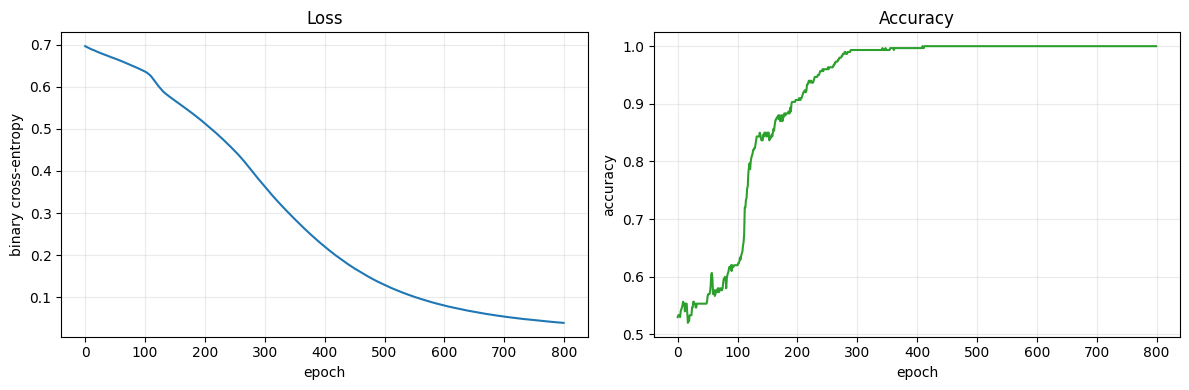

In [4]:
epochs = [step.epoch for step in history]
losses = [step.loss for step in history]
accuracies = [step.accuracy for step in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, losses, color="tab:blue")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("binary cross-entropy")
axes[0].grid(True, alpha=0.25)

axes[1].plot(epochs, accuracies, color="tab:green")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


**But** : tracer la frontière de décision apprise.

**Pourquoi** : montrer que le réseau apprend une séparation non linéaire dans le plan.


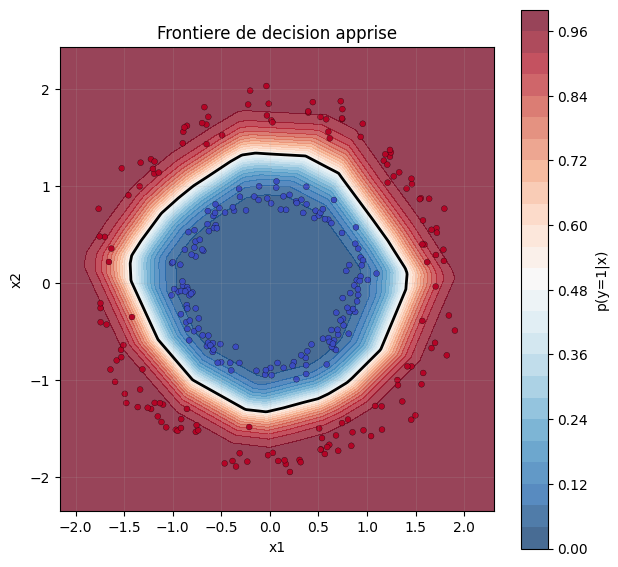

In [5]:
x1 = np.linspace(X[:, 0].min() - 0.4, X[:, 0].max() + 0.4, 250)
x2 = np.linspace(X[:, 1].min() - 0.4, X[:, 1].max() + 0.4, 250)
X1, X2 = np.meshgrid(x1, x2)
grid = np.column_stack([X1.ravel(), X2.ravel()])
P = model.predict_proba(grid).reshape(X1.shape)

fig, ax = plt.subplots(figsize=(7, 7))
contours = ax.contourf(X1, X2, P, levels=30, cmap="RdBu_r", alpha=0.75)
ax.contour(X1, X2, P, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap="coolwarm", s=18, edgecolor="black", linewidth=0.2)
ax.set_title("Frontiere de decision apprise")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
ax.grid(True, alpha=0.15)
fig.colorbar(contours, ax=ax, label="p(y=1|x)")
plt.show()
